In [1]:
# ============================================================================
# NOTEBOOK 05: GRAD-CAM EXPLAINABILITY
# Student: Sanjay Chaudhary (B01036144)
# ============================================================================
# Grad-CAM (Gradient-weighted Class Activation Mapping) helps us understand
# what parts of the retinal image the model is looking at to make its decision.
# This is the "explainable AI" part of my project.
# ============================================================================

import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
from torch.utils.data import DataLoader, Subset, Dataset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import cv2
import json
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

print("=" * 70)
print("GRAD-CAM EXPLAINABILITY")
print("=" * 70)
print("Student: Sanjay Chaudhary (B01036144)")
print("=" * 70)
print("\nGrad-CAM helps me understand WHERE my model is looking")
print("when it makes a diagnosis. This makes the AI explainable.")
print("=" * 70)

# Check hardware
if torch.backends.mps.is_available():
    device = torch.device('mps')
    print("\nUsing Apple MPS GPU")
elif torch.cuda.is_available():
    device = torch.device('cuda')
    print("\nUsing CUDA GPU")
else:
    device = torch.device('cpu')
    print("\nUsing CPU")

print(f"Device: {device}")

# Configuration
BATCH_SIZE = 32
IMG_SIZE = 224
NUM_CLASSES = 5
DATA_DIR = "../datasets/aptos_2019/images"

# Class names in ICDRSS order
class_names = ["No DR", "Mild", "Moderate", "Severe", "Proliferative"]

print(f"\nClass Names (ICDRSS Standard):")
for i, name in enumerate(class_names):
    print(f"  Class {i}: {name}")

GRAD-CAM EXPLAINABILITY
Student: Sanjay Chaudhary (B01036144)

Grad-CAM helps me understand WHERE my model is looking
when it makes a diagnosis. This makes the AI explainable.

Using Apple MPS GPU
Device: mps

Class Names (ICDRSS Standard):
  Class 0: No DR
  Class 1: Mild
  Class 2: Moderate
  Class 3: Severe
  Class 4: Proliferative


In [2]:
# ============================================================================
# STEP 2: DEFINE FIXED DATASET CLASS
# ============================================================================

class FixedAPTOSDataset(Dataset):
    """Fix class labels to ICDRSS standard"""
    
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        
        self.folder_to_label = {
            'Mild': 1,
            'Moderate': 2,
            'No_DR': 0,
            'Proliferate_DR': 4,
            'Severe': 3
        }
        
        self.raw_dataset = datasets.ImageFolder(root=root_dir, transform=None)
        self.samples = []
        self.labels = []
        
        for img, wrong_label in self.raw_dataset:
            folder_name = self.raw_dataset.classes[wrong_label]
            correct_label = self.folder_to_label[folder_name]
            self.samples.append(img)
            self.labels.append(correct_label)
        
        print(f"Fixed dataset loaded: {len(self.samples)} images")
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        img = self.samples[idx]
        label = self.labels[idx]
        
        if self.transform:
            img = self.transform(img)
        
        return img, label

In [3]:
# ============================================================================
# STEP 3: DEFINE GRAD-CAM CLASS
# ============================================================================

class GradCAM:
    """
    Gradient-weighted Class Activation Mapping (Grad-CAM)
    
    This technique generates a heatmap showing which regions of the image
    were most important for the model's prediction.
    """
    
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        # Register hooks to capture gradients and activations
        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_backward_hook(self.save_gradient)
    
    def save_activation(self, module, input, output):
        self.activations = output
    
    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]
    
    def generate_heatmap(self, input_image, target_class=None):
        self.model.eval()
        
        # Forward pass
        output = self.model(input_image)
        
        # If no target class specified, use the predicted class
        if target_class is None:
            target_class = torch.argmax(output, dim=1).item()
        
        # Zero gradients
        self.model.zero_grad()
        
        # Get the score for the target class
        score = output[0, target_class]
        
        # Backward pass
        score.backward()
        
        # Get gradients and activations
        gradients = self.gradients.detach().cpu().numpy()[0]
        activations = self.activations.detach().cpu().numpy()[0]
        
        # Weight the activations by the gradients
        weights = np.mean(gradients, axis=(1, 2))
        
        # Create heatmap
        cam = np.zeros(activations.shape[1:], dtype=np.float32)
        for i, w in enumerate(weights):
            cam += w * activations[i]
        
        # Apply ReLU (only positive contributions)
        cam = np.maximum(cam, 0)
        
        # Normalize
        cam = cam - np.min(cam)
        if np.max(cam) != 0:
            cam = cam / np.max(cam)
        
        return cam, target_class, torch.softmax(output, dim=1)[0].detach().cpu().numpy()

print("GradCAM class defined")

GradCAM class defined


In [6]:
# ============================================================================
# STEP 4: DEFINE MODEL WITH LAYER ACCESS
# ============================================================================

class DRResNet50WithLayers(nn.Module):
    """ResNet50 with accessible intermediate layers for Grad-CAM"""
    
    def __init__(self, num_classes=5):
        super(DRResNet50WithLayers, self).__init__()
        self.model = models.resnet50(weights=None)
        
        # Replace final layer for 5 classes
        num_features = self.model.fc.in_features
        self.model.fc = nn.Linear(num_features, num_classes)
    
    def forward(self, x):
        return self.model(x)

print("Model class defined")

Model class defined


In [7]:
# ============================================================================
# STEP 5: DEFINE EVALUATION TRANSFORMS
# ============================================================================

print("\n" + "=" * 70)
print("STEP 5: DEFINING TRANSFORMS")
print("=" * 70)

# Evaluation transform (no augmentation)
eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

print("Evaluation transform defined (no augmentation)")


STEP 5: DEFINING TRANSFORMS
Evaluation transform defined (no augmentation)


In [8]:
# ============================================================================
# STEP 6: LOAD MODEL AND DATA
# ============================================================================

print("\n" + "=" * 70)
print("STEP 6: LOADING MODEL AND DATA")
print("=" * 70)

# Load split indices
split_data = torch.load('../models/split_indices.pt', weights_only=False)
val_idx = split_data['val_idx']
class_names = split_data['class_names']

print(f"Validation indices: {len(val_idx)}")

# Create validation dataset
val_dataset_full = FixedAPTOSDataset(root_dir=DATA_DIR, transform=eval_transform)
val_dataset = Subset(val_dataset_full, val_idx)

print(f"Validation samples: {len(val_dataset)}")

# Create model
model = DRResNet50WithLayers(num_classes=NUM_CLASSES)
model = model.to(device)

# Load trained model
if os.path.exists('../models/best_model.pth'):
    checkpoint = torch.load('../models/best_model.pth', map_location=device, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"Loaded best model from epoch {checkpoint['epoch']}")
    print(f"  Validation accuracy: {checkpoint['val_acc']:.2f}%")
elif os.path.exists('../models/best_model_stage1.pth'):
    model.load_state_dict(torch.load('../models/best_model_stage1.pth', map_location=device))
    print("Loaded Stage 1 model")
else:
    print("WARNING: No trained model found!")

model.eval()
print("Model loaded and ready")


STEP 6: LOADING MODEL AND DATA
Validation indices: 733
Fixed dataset loaded: 3662 images
Validation samples: 733
Loaded best model from epoch 15
  Validation accuracy: 80.49%
Model loaded and ready


In [9]:
# ============================================================================
# STEP 7: HELPER FUNCTIONS FOR VISUALIZATION
# ============================================================================

print("\n" + "=" * 70)
print("STEP 7: DEFINING VISUALIZATION FUNCTIONS")
print("=" * 70)

def denormalize(tensor):
    """Reverse ImageNet normalization for display"""
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = tensor.permute(1, 2, 0).cpu().numpy()
    img = std * img + mean
    return np.clip(img, 0, 1)

def overlay_heatmap(image, heatmap, alpha=0.6):
    """Overlay heatmap on original image"""
    if torch.is_tensor(image):
        image = denormalize(image)
    
    heatmap = cv2.resize(heatmap, (image.shape[1], image.shape[0]))
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB) / 255.0
    
    overlayed = (1 - alpha) * image + alpha * heatmap_colored
    return np.clip(overlayed, 0, 1)

def show_gradcam_comparison(image, heatmap, overlayed, true_name, pred_name, confidence):
    """Display original image, heatmap, and overlay side by side"""
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    axes[0].imshow(image)
    axes[0].set_title(f"Original Image\nTrue: {true_name}\nPred: {pred_name}\nConf: {confidence:.2%}")
    axes[0].axis('off')
    
    axes[1].imshow(heatmap, cmap='jet')
    axes[1].set_title("Grad-CAM Heatmap\n(Model's Focus Area)")
    axes[1].axis('off')
    
    axes[2].imshow(overlayed)
    axes[2].set_title("Overlay\n(Where model is looking)")
    axes[2].axis('off')
    
    plt.tight_layout()
    return fig

print("Helper functions defined")


STEP 7: DEFINING VISUALIZATION FUNCTIONS
Helper functions defined



STEP 8: GENERATING GRAD-CAM HEATMAPS
Target layer: Conv2d(512, 2048, kernel_size=(1, 1), stride=(1, 1), bias=False)

Processing images...

Class 0 (No DR): Found 2 samples


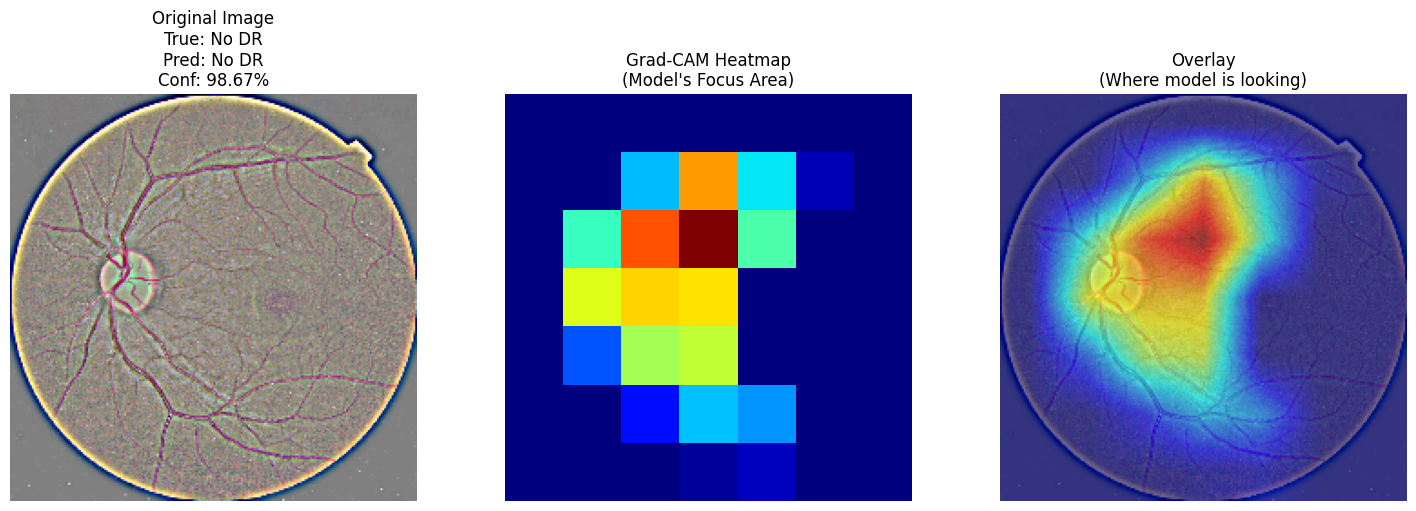

  Sample 1: True=No DR, Pred=No DR, Conf=98.67%


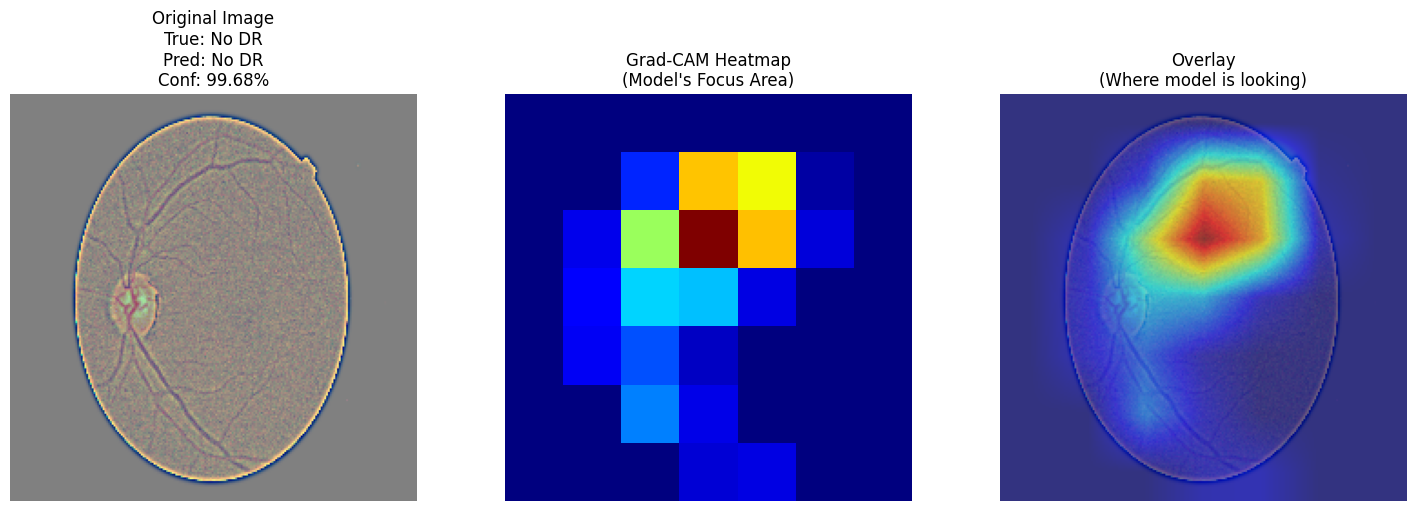

  Sample 2: True=No DR, Pred=No DR, Conf=99.68%

Class 1 (Mild): Found 2 samples


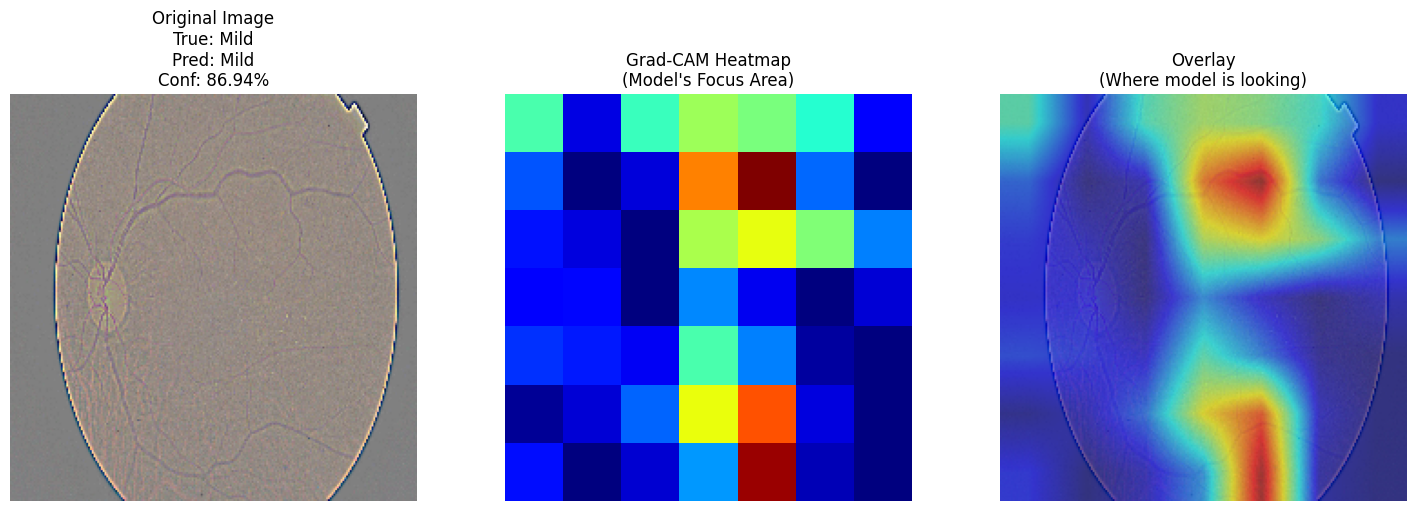

  Sample 1: True=Mild, Pred=Mild, Conf=86.94%


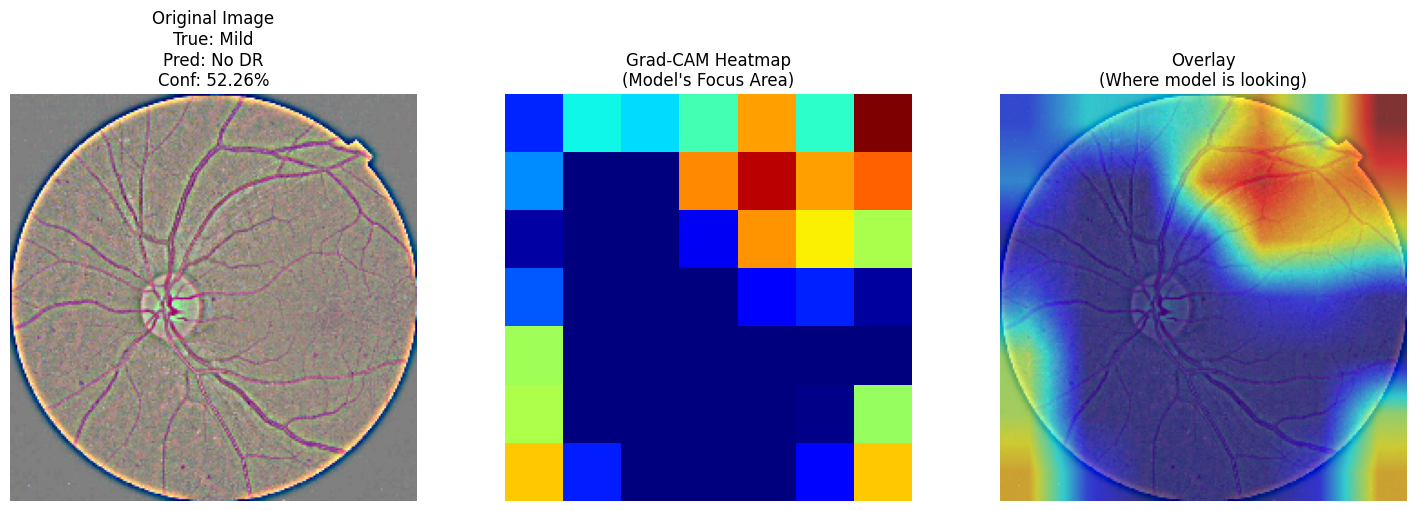

  Sample 2: True=Mild, Pred=No DR, Conf=52.26%

Class 2 (Moderate): Found 2 samples


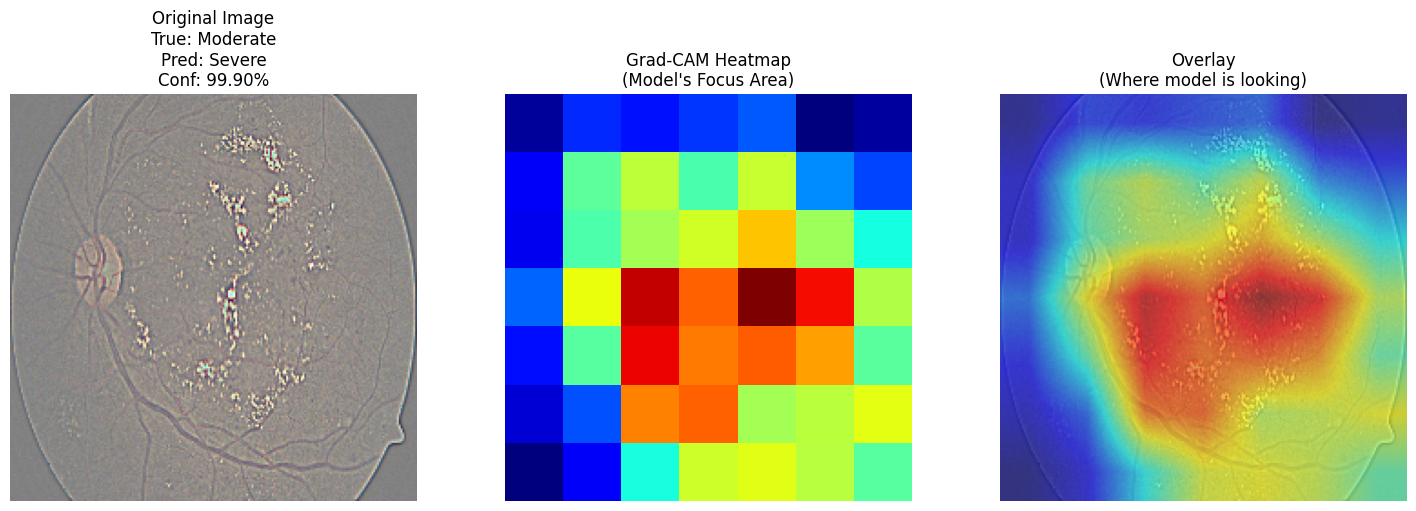

  Sample 1: True=Moderate, Pred=Severe, Conf=99.90%


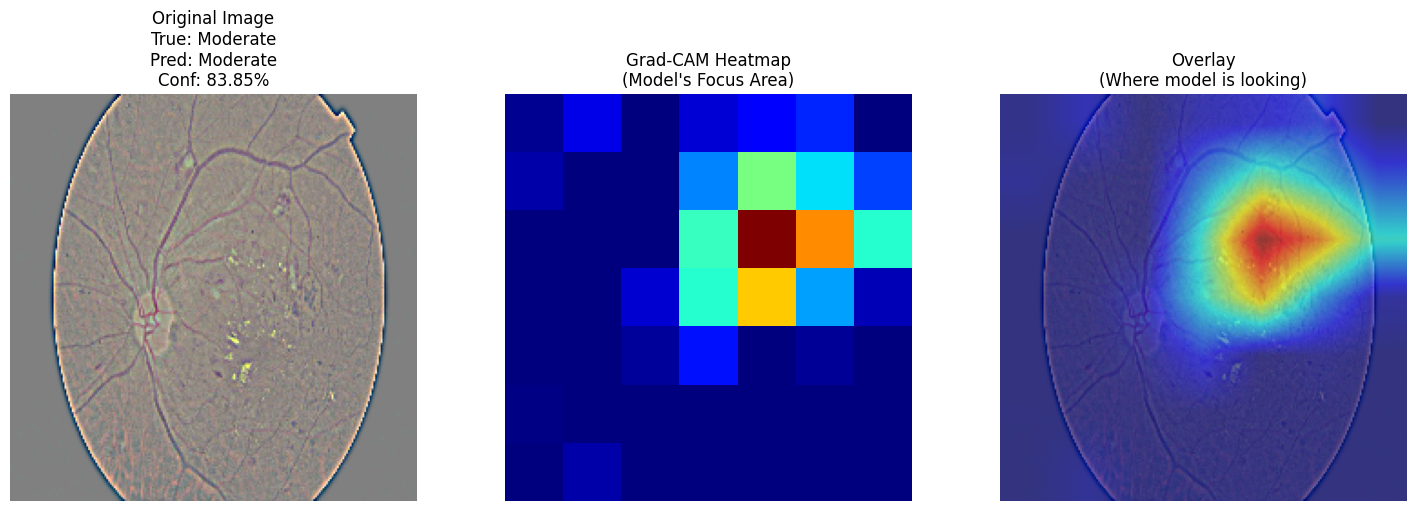

  Sample 2: True=Moderate, Pred=Moderate, Conf=83.85%

Class 3 (Severe): Found 2 samples


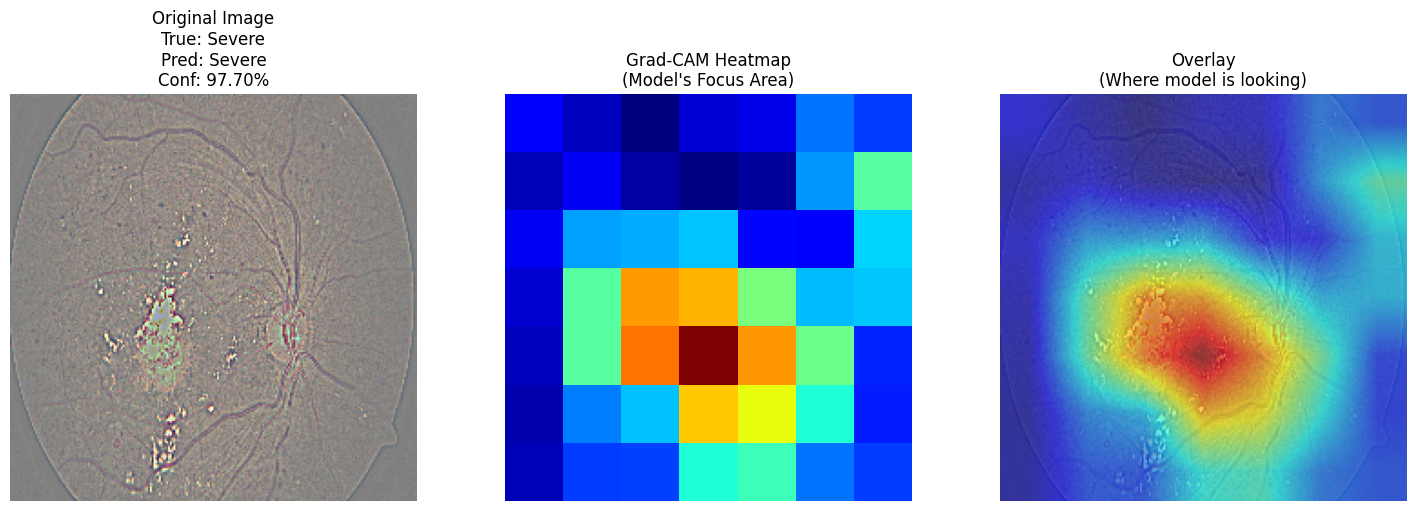

  Sample 1: True=Severe, Pred=Severe, Conf=97.70%


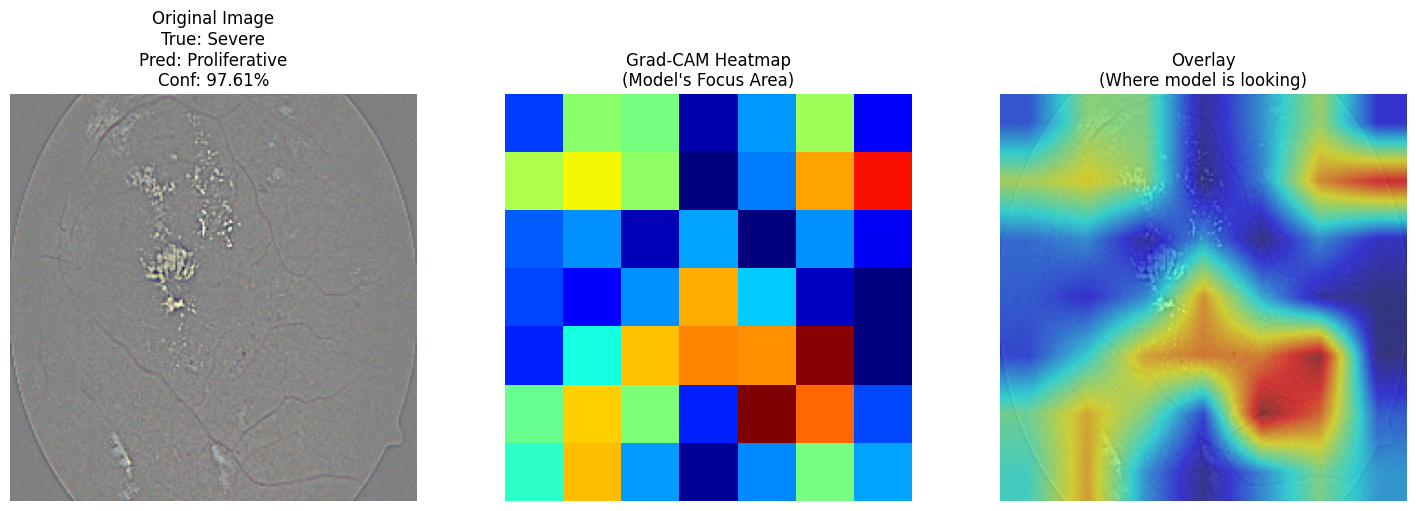

  Sample 2: True=Severe, Pred=Proliferative, Conf=97.61%

Class 4 (Proliferative): Found 2 samples


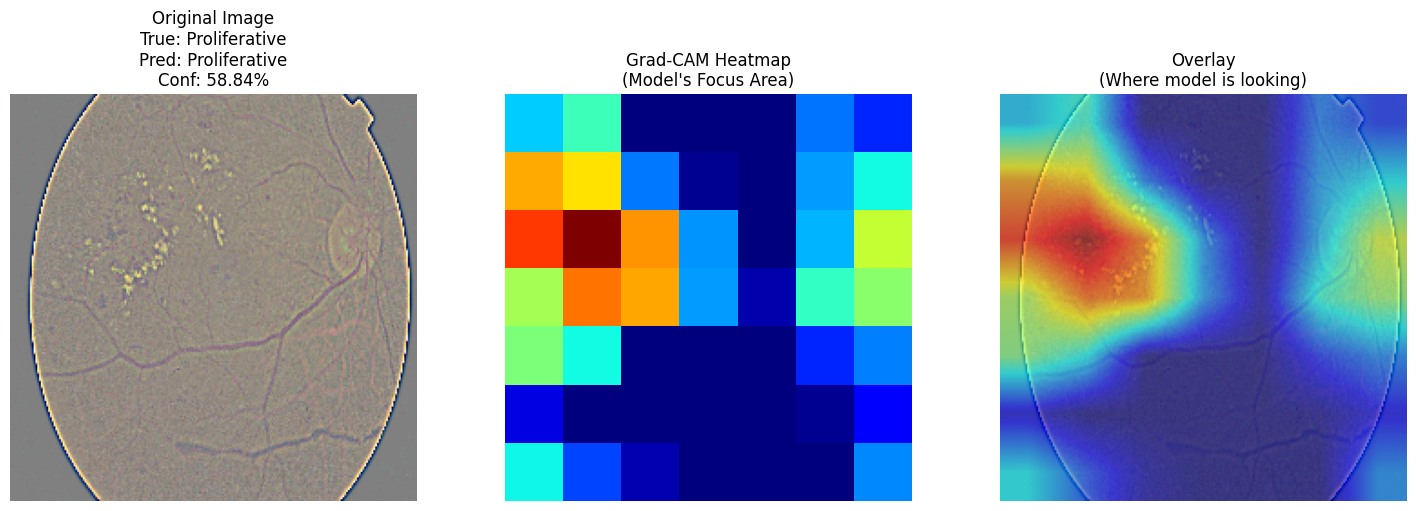

  Sample 1: True=Proliferative, Pred=Proliferative, Conf=58.84%


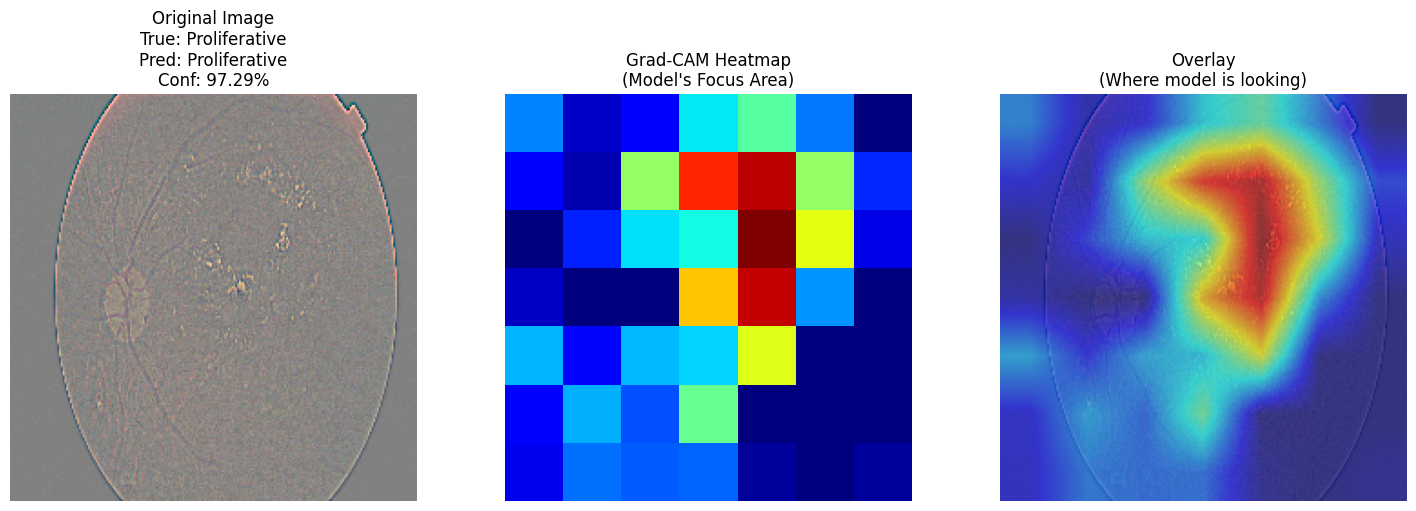

  Sample 2: True=Proliferative, Pred=Proliferative, Conf=97.29%

Grad-CAM generation complete!


In [10]:
# ============================================================================
# STEP 8: GENERATE GRAD-CAM HEATMAPS
# ============================================================================

print("\n" + "=" * 70)
print("STEP 8: GENERATING GRAD-CAM HEATMAPS")
print("=" * 70)

# Get the last convolutional layer for Grad-CAM
# For ResNet50, the last conv layer is layer4[2].conv3
target_layer = model.model.layer4[2].conv3
print(f"Target layer: {target_layer}")

gradcam = GradCAM(model, target_layer)

# Select 2 sample images from each class
samples_per_class = 2
gradcam_results = []

print("\nProcessing images...")

for class_idx in range(NUM_CLASSES):
    # Find images of this class
    class_indices = []
    for i in range(len(val_dataset)):
        _, label = val_dataset[i]
        if label == class_idx:
            class_indices.append(i)
        if len(class_indices) >= samples_per_class:
            break
    
    print(f"\nClass {class_idx} ({class_names[class_idx]}): Found {len(class_indices)} samples")
    
    for sample_idx, idx in enumerate(class_indices):
        # Get image and label
        image_tensor, true_label = val_dataset[idx]
        image_tensor = image_tensor.unsqueeze(0).to(device)
        
        # Generate heatmap
        heatmap, predicted_class, probabilities = gradcam.generate_heatmap(image_tensor)
        
        # Get image for display
        display_image = denormalize(image_tensor[0].cpu())
        confidence = probabilities[predicted_class]
        
        # Overlay heatmap
        overlayed = overlay_heatmap(display_image, heatmap)
        
        # Show and save
        true_name = class_names[true_label]
        pred_name = class_names[predicted_class]
        
        fig = show_gradcam_comparison(
            display_image, heatmap, overlayed,
            true_name, pred_name, confidence
        )
        
        # Save figure
        os.makedirs('../results/gradcam', exist_ok=True)
        plt.savefig(f'../results/gradcam/class_{class_idx}_sample_{sample_idx+1}.png', 
                    dpi=150, bbox_inches='tight')
        plt.show()
        plt.close(fig)
        
        # Store results
        gradcam_results.append({
            'class_idx': class_idx,
            'class_name': class_names[class_idx],
            'sample_idx': sample_idx + 1,
            'true_label': int(true_label),
            'predicted_label': int(predicted_class),
            'confidence': float(confidence),
            'heatmap_saved': f'gradcam/class_{class_idx}_sample_{sample_idx+1}.png'
        })
        
        print(f"  Sample {sample_idx + 1}: True={true_name}, Pred={pred_name}, Conf={confidence:.2%}")

print("\nGrad-CAM generation complete!")

In [11]:
# ============================================================================
# STEP 9: ANALYZE GRAD-CAM RESULTS
# ============================================================================

print("\n" + "=" * 70)
print("STEP 9: ANALYZING RESULTS")
print("=" * 70)

# Create summary
summary = {
    'total_samples': len(gradcam_results),
    'correct_predictions': sum(1 for r in gradcam_results if r['true_label'] == r['predicted_label']),
    'samples_by_class': {}
}

for class_idx in range(NUM_CLASSES):
    class_results = [r for r in gradcam_results if r['class_idx'] == class_idx]
    correct = sum(1 for r in class_results if r['true_label'] == r['predicted_label'])
    
    summary['samples_by_class'][class_names[class_idx]] = {
        'total': len(class_results),
        'correct': correct,
        'accuracy': correct / len(class_results) if len(class_results) > 0 else 0
    }

print("\nGrad-CAM Summary:")
print("-" * 50)
print(f"Total samples analyzed: {summary['total_samples']}")
print(f"Correct predictions: {summary['correct_predictions']}")
print(f"Overall accuracy: {summary['correct_predictions']/summary['total_samples']*100:.1f}%")

print("\nPer-class results:")
for class_name, stats in summary['samples_by_class'].items():
    print(f"  {class_name}: {stats['correct']}/{stats['total']} correct ({stats['accuracy']*100:.0f}%)")

# Save results
with open('../results/gradcam_results.json', 'w') as f:
    json.dump(gradcam_results, f, indent=2)

print("\nSaved: results/gradcam_results.json")


STEP 9: ANALYZING RESULTS

Grad-CAM Summary:
--------------------------------------------------
Total samples analyzed: 10
Correct predictions: 7
Overall accuracy: 70.0%

Per-class results:
  No DR: 2/2 correct (100%)
  Mild: 1/2 correct (50%)
  Moderate: 1/2 correct (50%)
  Severe: 1/2 correct (50%)
  Proliferative: 2/2 correct (100%)

Saved: results/gradcam_results.json


In [12]:
# ============================================================================
# STEP 10: INTERPRETATION GUIDE
# ============================================================================

print("\n" + "=" * 70)
print("STEP 10: INTERPRETATION GUIDE")
print("=" * 70)

print("""
WHAT GRAD-CAM HEATMAPS TELL US:

For DIABETIC RETINOPATHY detection:

1. NO DR (Healthy):
   - Model should focus on clear blood vessels
   - No abnormal spots highlighted

2. MILD DR:
   - Should highlight small red dots (microaneurysms)
   - Usually near the macula

3. MODERATE DR:
   - Should highlight hemorrhages (dark red spots)
   - Should highlight exudates (yellow-white spots)

4. SEVERE DR:
   - Should highlight extensive hemorrhages
   - All four quadrants of the retina

5. PROLIFERATIVE DR:
   - Should highlight abnormal new blood vessels
   - Usually on or near optic disc

CLINICAL VALIDATION:
- If heatmaps match what doctors look for → Model is learning correctly
- If heatmaps highlight background or edges → Model may be learning wrong patterns
""")

print("\n" + "=" * 70)
print("NOTEBOOK 05 COMPLETE")
print("=" * 70)

print("\nFILES SAVED:")
print("-" * 60)
print("  - results/gradcam/class_*_sample_*.png (Grad-CAM visualizations)")
print("  - results/gradcam_results.json (Results summary)")

print("\n" + "=" * 70)
print("NEXT: Open Notebook 06 - Cross-Dataset Testing")
print("=" * 70)


STEP 10: INTERPRETATION GUIDE

WHAT GRAD-CAM HEATMAPS TELL US:

For DIABETIC RETINOPATHY detection:

1. NO DR (Healthy):
   - Model should focus on clear blood vessels
   - No abnormal spots highlighted

2. MILD DR:
   - Should highlight small red dots (microaneurysms)
   - Usually near the macula

3. MODERATE DR:
   - Should highlight hemorrhages (dark red spots)
   - Should highlight exudates (yellow-white spots)

4. SEVERE DR:
   - Should highlight extensive hemorrhages
   - All four quadrants of the retina

5. PROLIFERATIVE DR:
   - Should highlight abnormal new blood vessels
   - Usually on or near optic disc

CLINICAL VALIDATION:
- If heatmaps match what doctors look for → Model is learning correctly
- If heatmaps highlight background or edges → Model may be learning wrong patterns


NOTEBOOK 05 COMPLETE

FILES SAVED:
------------------------------------------------------------
  - results/gradcam/class_*_sample_*.png (Grad-CAM visualizations)
  - results/gradcam_results.json (R